In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

# Visualize

In [62]:
raw2cls_df = pd.read_excel('E:/Gun/model-benchmark/scratch/lt200264-saiwat/worm-project/worm-classification-model/model-benchmark/all_results.xlsx', sheet_name='2class_raw')

In [63]:
def plot_model_ranking(df):
    ranked = df.sort_values('test_f1_2class', ascending=False)

    fig, ax = plt.subplots(figsize=(20, 6))

    # draw bar
    sns.barplot(data=ranked, x='variant', y='test_f1_2class', hue='family', dodge=False, ax=ax, gap=0.1)

    # write score
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', fontsize=9, fontweight='bold', padding=3)

    ax.legend(title="family", bbox_to_anchor=(1.01, 1), loc="upper left")

    # เอียง text
    plt.xticks(rotation=60, ha="right", fontsize=9)

    # ตัดช่วงข้อมูล
    ax.set_ylim(0.65, 0.85)

    ax.set_xlabel("Models", fontsize=12, labelpad=15)
    ax.set_ylabel("Test F1 Score (2 classes)", fontsize=12, labelpad=15)
    ax.set_title("Models Ranking", fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

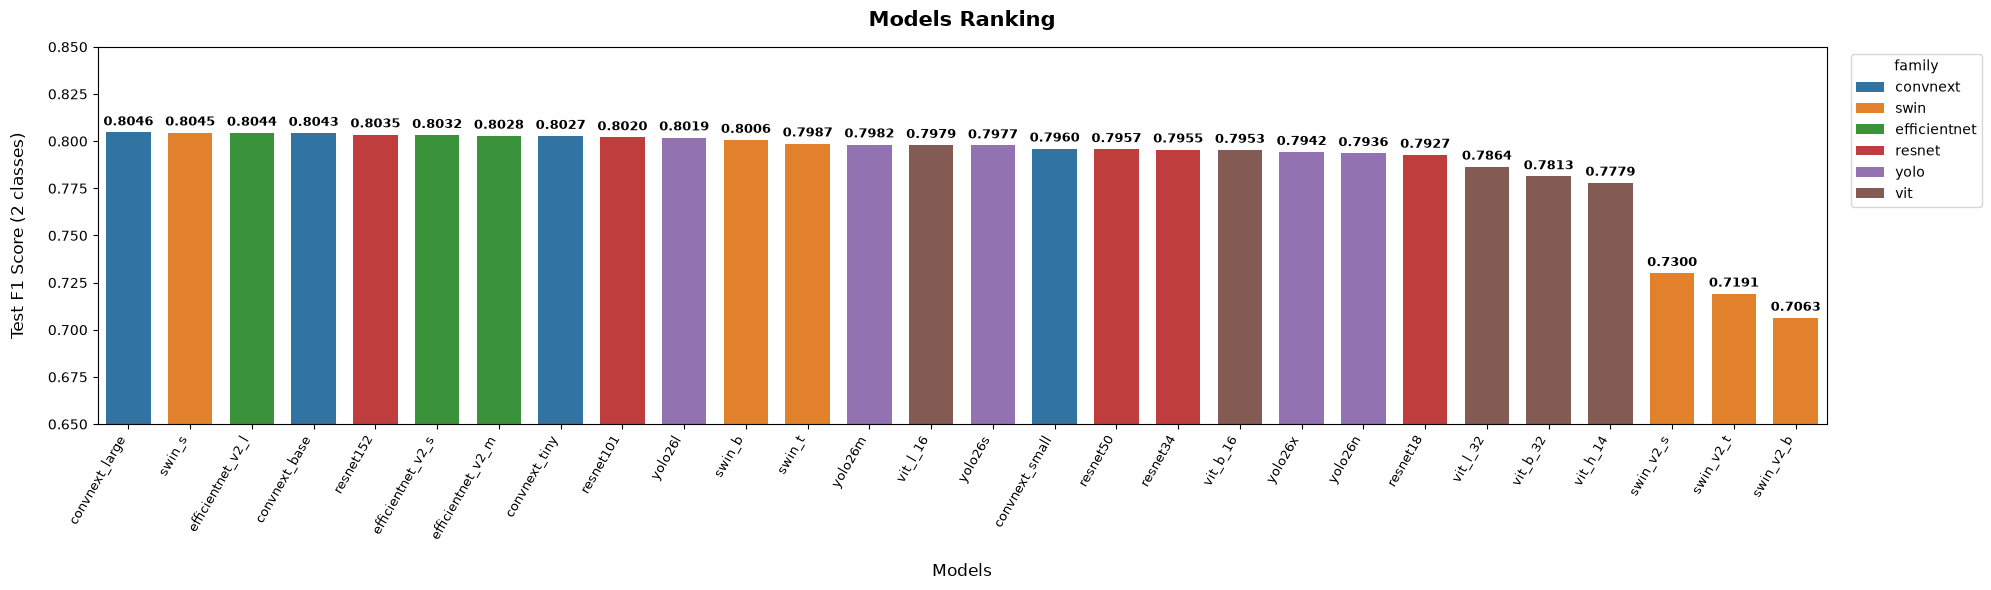

In [64]:
plot_model_ranking(raw2cls_df)

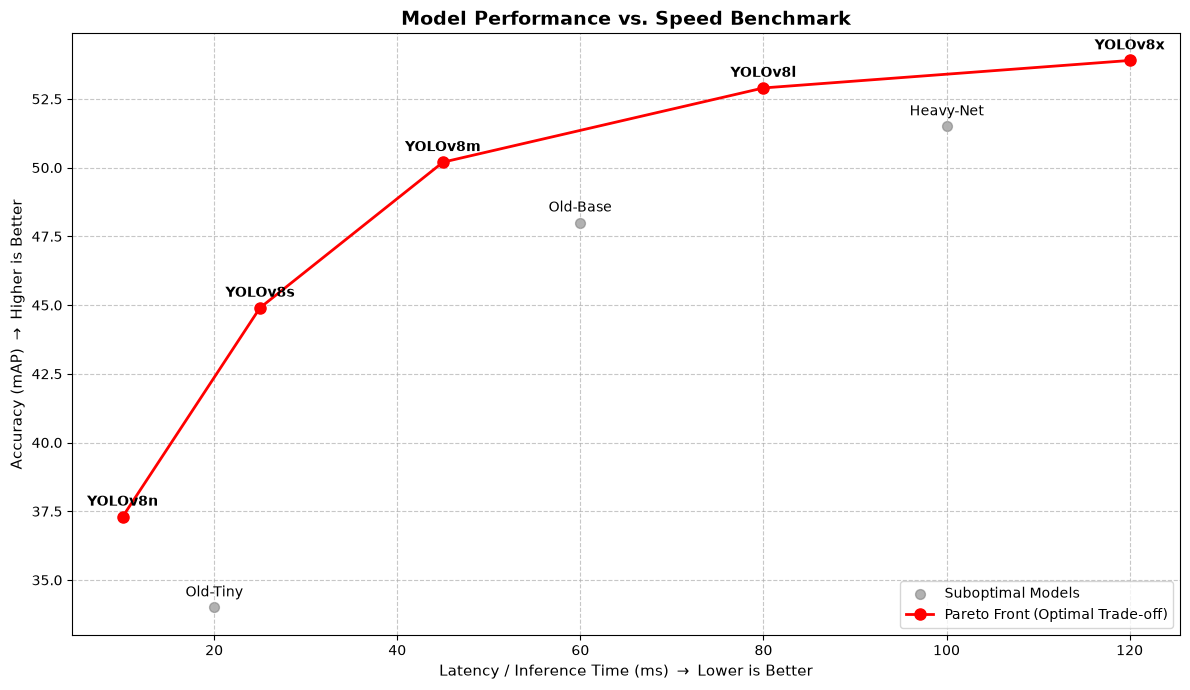

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sample Data (Simulating YOLO-style benchmarks)
# 'latency_ms' is our cost (lower is better)
# 'mAP' is our performance (higher is better)
data = {
    'model': ['YOLOv8n', 'YOLOv8s', 'YOLOv8m', 'YOLOv8l', 'YOLOv8x', 'Old-Tiny', 'Old-Base', 'Heavy-Net'],
    'latency_ms': [10, 25, 45, 80, 120, 20, 60, 100],
    'mAP': [37.3, 44.9, 50.2, 52.9, 53.9, 34.0, 48.0, 51.5]
}
df = pd.DataFrame(data)

# 2. Calculate the Pareto Front
# Sort by the cost metric (latency) in ascending order (lowest latency first)
df_sorted = df.sort_values('latency_ms')

pareto_front_x = []
pareto_front_y = []
current_max_map = 0 

# A point is on the Pareto front if its accuracy is higher than all faster models
for index, row in df_sorted.iterrows():
    if row['mAP'] > current_max_map:
        pareto_front_x.append(row['latency_ms'])
        pareto_front_y.append(row['mAP'])
        current_max_map = row['mAP']

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot for ALL models
ax.scatter(df['latency_ms'], df['mAP'], color='gray', s=50, alpha=0.6, label='Suboptimal Models')

# Scatter and Line plot for PARETO FRONT models
ax.plot(pareto_front_x, pareto_front_y, marker='o', markersize=8, color='red', 
        linestyle='-', linewidth=2, label='Pareto Front (Optimal Trade-off)')

# Annotate each model with its name
for index, row in df.iterrows():
    # Highlight Pareto models with bolder text if desired, here we just label all
    is_pareto = (row['latency_ms'] in pareto_front_x) and (row['mAP'] in pareto_front_y)
    font_weight = 'bold' if is_pareto else 'normal'
    
    ax.annotate(row['model'], 
                (row['latency_ms'], row['mAP']), 
                textcoords="offset points", 
                xytext=(0, 8), 
                ha='center', 
                fontsize=10,
                fontweight=font_weight)

# Formatting to look like standard benchmark charts
ax.set_xlabel("Latency / Inference Time (ms) $\\rightarrow$ Lower is Better", fontsize=11)
ax.set_ylabel("Accuracy (mAP) $\\rightarrow$ Higher is Better", fontsize=11)
ax.set_title("Model Performance vs. Speed Benchmark", fontsize=14, fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()